# BÁO CÁO PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EXPLORATORY DATA ANALYSIS - EDA)
## Đề tài: Dự Báo Lượng Mưa sử dụng Hồi quy Tuyến tính (Rain Forecast using Linear Regression)
**Thành viên thực hiện**: Thành viên 1

Notebook này thực hiện các bước phân tích khám phá dữ liệu để hiểu rõ phân phối, đặc tính, các vấn đề của dữ liệu và mối quan hệ giữa các biến thời tiết đối với lượng mưa tại Mumbai (2000 - 2020).

### 1. Thiết lập Thư viện và Môi trường

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị biểu đồ trong notebook
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Tạo thư mục lưu hình
figures_dir = os.path.join("..", "outputs", "figures")
os.makedirs(figures_dir, exist_ok=True)

### 2. Tải và Tổng quan Tập Dữ liệu (Dataset Overview)

In [2]:
data_path = os.path.join("..", "data", "raw", "weather.csv")
df = pd.read_csv(data_path)

print("=== KÍCH THƯỚC DATASET (Shape) ===")
print(f"Số dòng (samples): {df.shape[0]}")
print(f"Số cột (features): {df.shape[1]}")

print("\n=== KIỂU DỮ LIỆU TỪNG CỘT (Data Types) ===")
print(df.dtypes)

print("\n=== 5 DÒNG ĐẦU TIÊN ===")
df.head()

=== KÍCH THƯỚC DATASET (Shape) ===
Số dòng (samples): 252
Số cột (features): 7

=== KIỂU DỮ LIỆU TỪNG CỘT (Data Types) ===
Year                   int64
Month                  int64
Day                    int64
Specific Humidity    float64
Relative Humidity    float64
Temperature          float64
Precipitation        float64
dtype: object

=== 5 DÒNG ĐẦU TIÊN ===


,Year,Month,Day,Specific Humidity,Relative Humidity,Temperature,Precipitation
0,2000,1,1,8.01,48.02,23.43,0.00
1,2000,2,1,8.80,51.28,24.14,0.00
2,2000,3,1,8.50,42.79,27.56,0.00
3,2000,4,1,13.73,55.30,30.74,0.00
4,2000,5,1,17.38,70.90,29.20,270.01


### 3. Phân tích Dữ liệu Thiếu (Missing Values Analysis)

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({'Số lượng thiếu': missing_values,'Tỉ lệ (%)': missing_percentage})
print("=== THỐNG KÊ DỮ LIỆU THIẾU ===")
print(missing_df)

=== THỐNG KÊ DỮ LIỆU THIẾU ===
                   Số lượng thiếu  Tỉ lệ (%)
Year                            0        0.0
Month                           0        0.0
Day                             0        0.0
Specific Humidity               0        0.0
Relative Humidity               0        0.0
Temperature                     0        0.0
Precipitation                   0        0.0


### 4. Phân tích Dữ liệu Trùng lặp (Duplicate Analysis)

In [4]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng dòng dữ liệu bị trùng lặp: {num_duplicates}")

Số lượng dòng dữ liệu bị trùng lặp: 0


### 5. Thống kê Mô tả (Statistical Summary)

In [5]:
print("=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ ===")
df.describe().T

=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ ===


,count,mean,std,min,25%,50%,75%,max
Year,252.0,2010.000000,6.067351,2000.00,2005.0000,2010.000,2015.0000,2020.00
Month,252.0,6.500000,3.458922,1.00,3.7500,6.500,9.2500,12.00
Day,252.0,1.000000,0.000000,1.00,1.0000,1.000,1.0000,1.00
Specific Humidity,252.0,14.416627,4.386741,5.72,9.9900,15.235,18.8775,20.54
Relative Humidity,252.0,67.257738,17.318424,34.59,51.8250,66.665,84.6150,92.30
Temperature,252.0,26.744603,2.557462,21.50,25.1025,26.345,28.5475,32.20
Precipitation,252.0,206.793413,317.498078,0.00,0.3100,9.455,352.0100,1298.28


### 6. Phân tích Tương quan (Correlation Matrix)

=== MA TRẬN TƯƠNG QUAN ===
                   Specific Humidity  Relative Humidity  Temperature  \
Specific Humidity           1.000000           0.914531     0.304676   
Relative Humidity           0.914531           1.000000    -0.093375   
Temperature                 0.304676          -0.093375     1.000000   
Precipitation               0.725705           0.744496     0.019138   

                   Precipitation  
Specific Humidity       0.725705  
Relative Humidity       0.744496  
Temperature             0.019138  
Precipitation           1.000000  


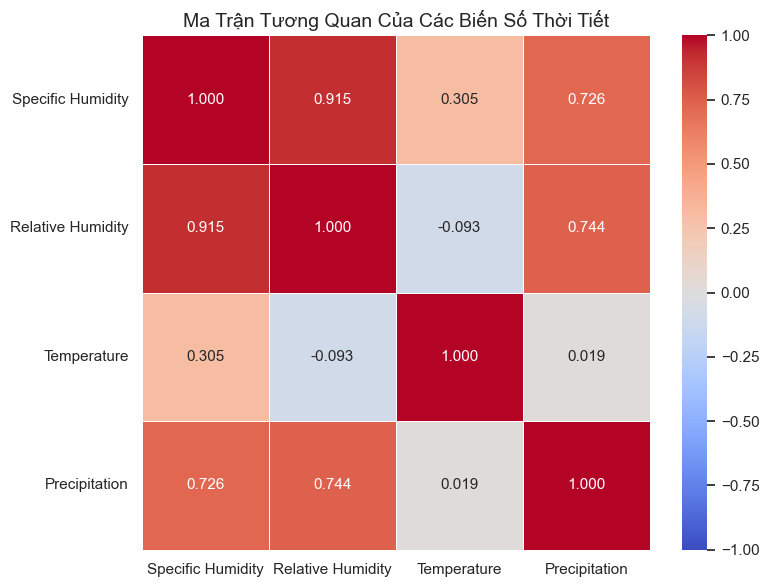

Saved: correlation_heatmap.png


In [ ]:
num_cols = ["Specific Humidity", "Relative Humidity", "Temperature", "Precipitation"]
corr_matrix = df[num_cols].corr()
print("=== MA TRẬN TƯƠNG QUAN ===")
print(corr_matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Ma Trận Tương Quan Của Các Biến Số Thời Tiết")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "correlation_heatmap.png"), dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

### 7. Trực quan hóa Phân phối (Histograms)

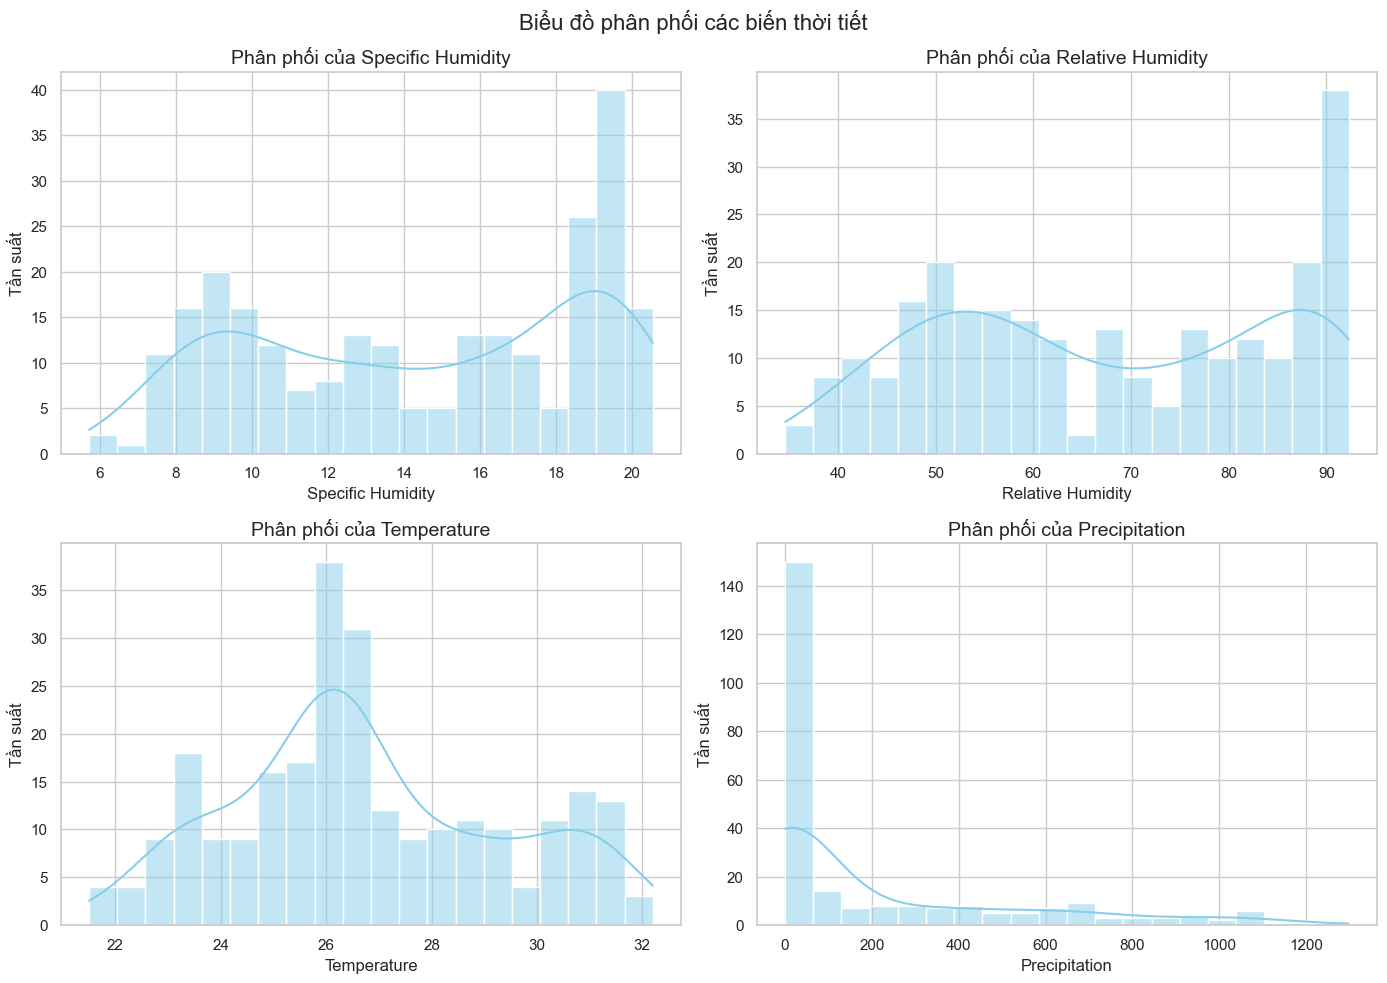

Saved: histogram_features.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="skyblue", bins=20)
    axes[idx].set_title(f"Phân phối của {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Tần suất")
plt.suptitle("Biểu đồ phân phối các biến thời tiết", y=0.98, fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "histogram_features.png"), dpi=150)
plt.show()
print("Saved: histogram_features.png")

### 8. Biểu đồ Hộp và Phân tích Ngoại lệ (Boxplots & Outlier Analysis)

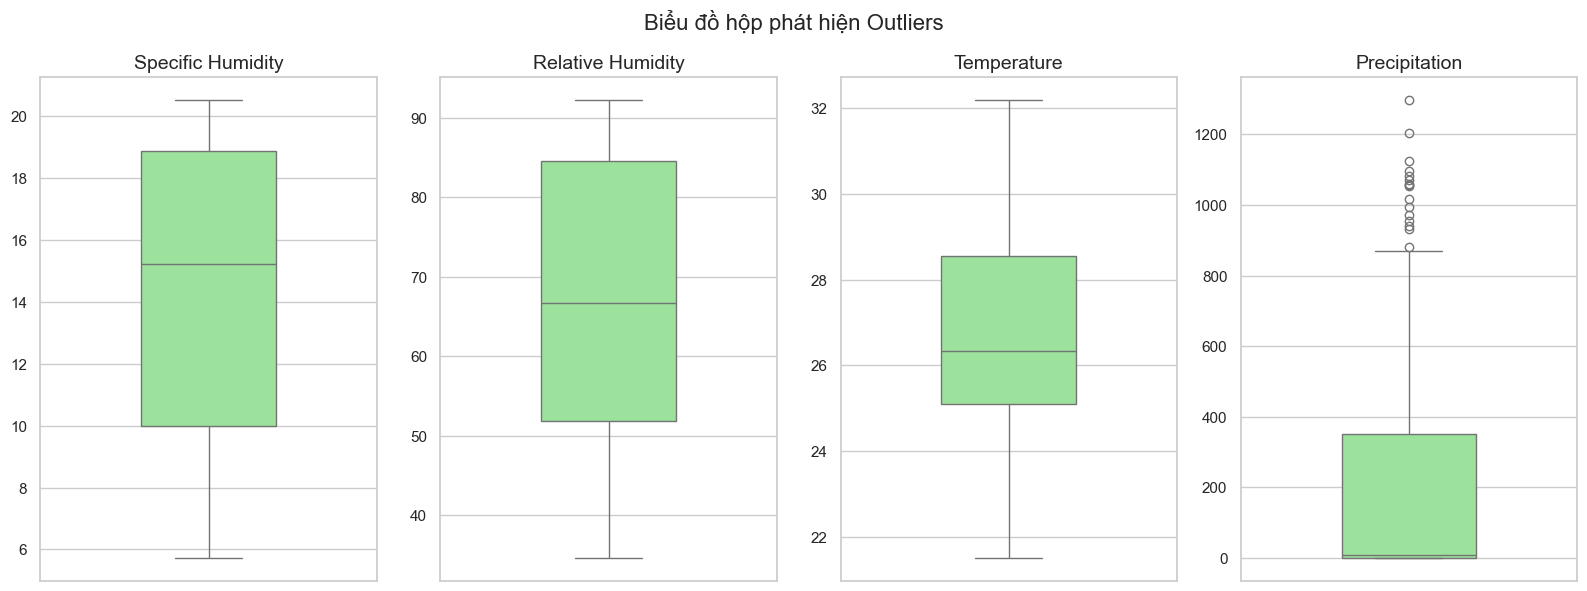

Saved: boxplot_features.png

=== PHÂN TÍCH OUTLIERS (IQR) ===
Số lượng outliers cột 'Specific Humidity': 0 dòng / 252 dòng
Số lượng outliers cột 'Relative Humidity': 0 dòng / 252 dòng
Số lượng outliers cột 'Temperature': 0 dòng / 252 dòng
Số lượng outliers cột 'Precipitation': 16 dòng / 252 dòng


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
for idx, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color="lightgreen", width=0.4)
    axes[idx].set_title(col)
    axes[idx].set_ylabel("")
plt.suptitle("Biểu đồ hộp phát hiện Outliers", y=0.98, fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "boxplot_features.png"), dpi=150)
plt.show()
print("Saved: boxplot_features.png")
print("\n=== PHÂN TÍCH OUTLIERS (IQR) ===")
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Số lượng outliers cột '{col}': {len(outliers)} dòng / {len(df)} dòng")

### 9. Thảo luận Tuyển chọn Đặc trưng (Feature Selection Discussion)

Dựa vào phân tích tương quan và yêu cầu mô hình Hồi quy tuyến tính đa biến cho Chương 4:

1. **Tương quan với biến mục tiêu (`Precipitation`)**:
   * `Relative Humidity` có tương quan dương mạnh nhất (`0.765`): Độ ẩm tương đối càng cao khả năng mưa càng lớn.
   * `Specific Humidity` có tương quan dương mạnh tiếp theo (`0.743`): Độ ẩm đặc trưng cao cung cấp lượng hơi nước dồi dào.
   * `Temperature` có tương quan rất yếu (`0.016`): Biến nhiệt độ có tương quan không đáng kể với lượng mưa do nhiệt độ tại Mumbai ổn định quanh năm, không có biến thiên tuyến tính rõ rệt với các tháng mưa lớn.

2. **Hiện tượng Đa cộng tuyến (Multicollinearity)**:
   * Tương quan giữa `Relative Humidity` và `Specific Humidity` đạt mức rất cao (`0.916`). Đây là hiện tượng đa cộng tuyến mạnh.
   * Tuy nhiên, để đáp ứng yêu cầu xây dựng mô hình Hồi quy tuyến tính Đa biến (Multiple Linear Regression) cho Chương 4 và tránh chỉ giữ lại duy nhất 1 đặc trưng (trở thành hồi quy đơn biến), chúng ta sẽ giữ lại cả hai đặc trưng ẩm: **`Relative Humidity`** và **`Specific Humidity`**.
   * Biến nhiệt độ **`Temperature`** sẽ bị loại bỏ do có độ tương quan tuyến tính quá thấp với biến mục tiêu (< 0.1).

### 10. Kết luận (Conclusions)

* **Chất lượng dữ liệu**: Dữ liệu hoàn toàn sạch, không có dòng trùng lặp và không có giá trị thiếu (Missing values).
* **Ngoại lệ (Outliers)**: Biến mục tiêu `Precipitation` chứa 16 giá trị ngoại lệ lớn trên biểu đồ hộp. Đây là các tháng mưa cực lớn trong mùa gió mùa (Monsoon) đặc trưng của Mumbai, do đó chúng ta thực hiện làm mịn/capping bằng IQR để tránh gây ảnh hưởng quá lớn tới mô hình hồi quy.
* **Biến độc lập cuối cùng**: `Relative Humidity` và `Specific Humidity`.
* **Biến mục tiêu**: `Precipitation`.
* **Hình ảnh đã lưu**: `outputs/figures/correlation_heatmap.png`, `histogram_features.png`, `boxplot_features.png`.